In [1]:
!unzip dataset -d data

Archive:  dataset.zip
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (1).webp  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (104).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (106).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (115).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (119).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (124).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (135).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (139).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (144).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (147).jpg  
  inflating: data/skin-disease-datasaet/test_set/BA- cellulitis/BA- c

In [1]:
import os
import os.path as op
import shutil
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [2]:
dataset_folder = "data/skin-disease-datasaet"

In [3]:
image_path = []

In [4]:
for filename in os.listdir(dataset_folder):
    if filename.endswith(('.jpg', '.jpeg', '.png')):
        current_image_path = op.join(dataset_folder, filename)
        image_path.append(current_image_path)
        print(current_image_path)
labels = [op.basename(op.dirname(path)) for path in image_path]
train_df = pd.DataFrame({'image_path': image_path, 'label': labels})

In [5]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [6]:
from fastbook import *

In [7]:
fields = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms()
)

In [8]:
import matplotlib.pyplot as plt
import cv2
import os.path as op

In [9]:
def print_and_get_images(folder_path):
  image_paths = []  # List to store image paths
  for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            # Construct full image path
            current_image_path = op.join(folder_path, filename)

            # Print image path
            print(current_image_path)

            # Add image path to the list
            image_paths.append(current_image_path)

            # Read and display image using OpenCV and Matplotlib
            image = cv2.imread(current_image_path)

            # Convert color space from BGR (OpenCV default) to RGB (Matplotlib default)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            plt.imshow(image_rgb)
            plt.title(filename)  # Set title to filename
            plt.axis('off')  # Hide axes
            plt.show()

  return image_paths  # Return list of image paths

In [10]:
dataset_folder = "data/skin-disease-datasaet"  # Replace with your folder path
image_paths = print_and_get_images(dataset_folder)

In [11]:
parent_label("data/test/000621fb3cbb32d8935728e48679680e.jpg")

'test'

In [12]:
from fastai.vision.all import *

In [13]:
#!pip install -Uqq fastai fastcore

ERROR: Operation cancelled by user


In [22]:
dataset_folder = "data/skin-disease-datasaet/test_set"

In [23]:
!pip install --upgrade fastcore python-fasthtml fastai fastlite fastprogress

In [24]:
!pip show fastai
!pip show fastcore

Name: fastai
Version: 2.8.8
Summary: fastai simplifies training fast and accurate neural nets using modern best practices
Home-page: 
Author: 
Author-email: "Jeremy Howard, Sylvain Gugger, and contributors" <info@fast.ai>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: cloudpickle, fastcore, fastdownload, fastprogress, fasttransform, matplotlib, packaging, pandas, pillow, plum-dispatch, pyyaml, requests, scikit-learn, scipy, spacy, torch, torchvision
Required-by: fastbook
Name: fastcore
Version: 2.2.12
Summary: Python supercharged for fastai development
Home-page: 
Author: 
Author-email: Jeremy Howard and Sylvain Gugger <infos@fast.ai>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: apswutils, fastai, fastdownload, fastlite, fastprogress, fasttransform, python-fasthtml


In [25]:
dls = ImageDataLoaders.from_path_func(
    dataset_folder,
    get_image_files(dataset_folder),
    valid_pct=0.2,
    seed=42,
    label_func=parent_label,
    item_tfms=Resize(224)
)

In [26]:
dls.vocab

['BA- cellulitis', 'BA-impetigo', 'FU-athlete-foot', 'FU-nail-fungus', 'FU-ringworm', 'PA-cutaneous-larva-migrans', 'VI-chickenpox', 'VI-shingles']

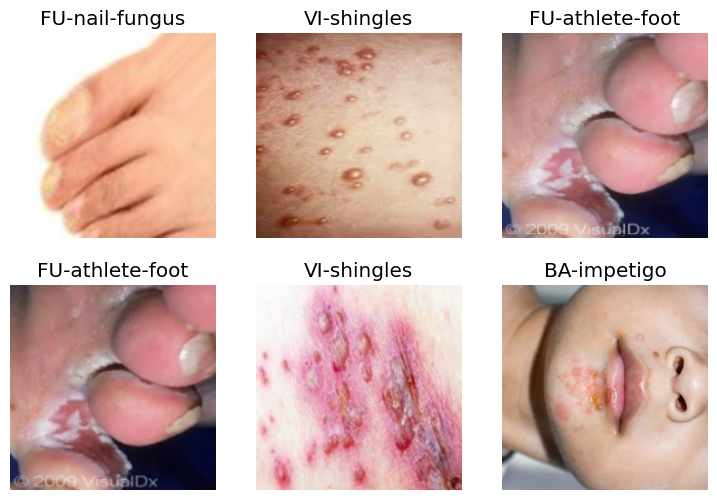

In [27]:
dls.train.show_batch(max_n=6, nrows=2)

In [29]:
learner = vision_learner(dls, resnet34, metrics=[error_rate, accuracy])

<div></div>

SuggestedLRs(valley=0.0010000000474974513)

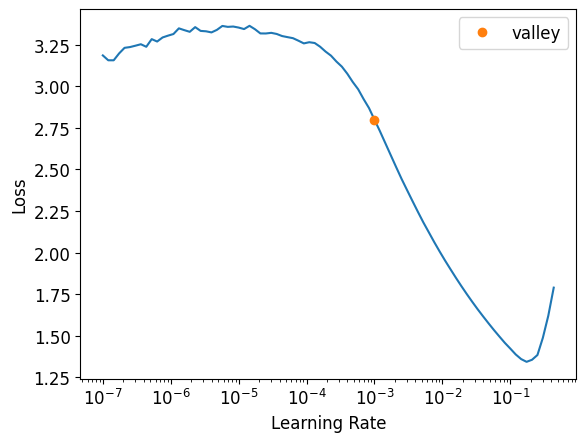

In [30]:
learner.lr_find()

In [31]:
learner.fine_tune(epochs=6, freeze_epochs=1, base_lr=0.0012)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,3.398888,2.743720,0.847826,0.152174,00:33


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,2.756682,2.278635,0.826087,0.173913,00:50
1,2.503357,1.812898,0.652174,0.347826,00:50
2,2.152486,1.457442,0.478261,0.521739,00:51
3,1.833006,1.246658,0.369565,0.630435,00:49
4,1.547511,1.118908,0.347826,0.652174,00:49
5,1.353522,1.060889,0.347826,0.652174,00:49


In [32]:
interp = ClassificationInterpretation.from_learner(learner)
interp.print_classification_report()

                            precision    recall  f1-score   support

            BA- cellulitis       1.00      0.56      0.71         9
               BA-impetigo       0.80      0.80      0.80         5
           FU-athlete-foot       0.44      0.67      0.53         6
            FU-nail-fungus       0.67      1.00      0.80         6
               FU-ringworm       1.00      0.25      0.40         4
PA-cutaneous-larva-migrans       1.00      0.43      0.60         7
             VI-chickenpox       0.56      0.83      0.67         6
               VI-shingles       0.40      0.67      0.50         3

                  accuracy                           0.65        46
                 macro avg       0.73      0.65      0.63        46
              weighted avg       0.77      0.65      0.65        46



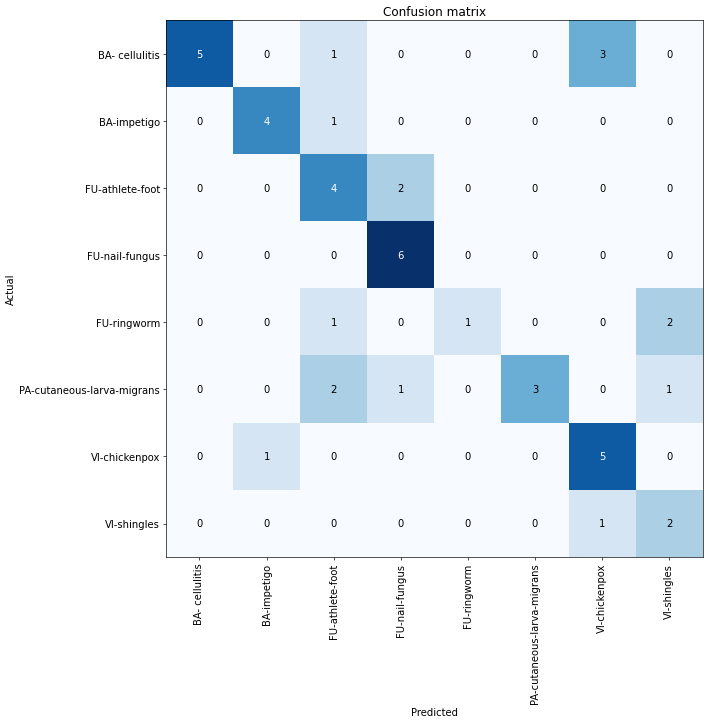

In [33]:
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

In [34]:
print(learner)

In [35]:
learner.export("Skin_disease.pkl")

In [36]:
import os
print(os.path.exists("Skin_disease.pkl"))

False


In [37]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'dataset.zip', 'gdrive', 'data', 'sample_data']


In [38]:
learner.export("/content/Skin_disease.pkl")
print(os.path.exists("/content/Skin_disease.pkl"))

True


In [39]:
from google.colab import files
files.download("/content/Skin_disease.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# Verify where the model was exported
!ls {dataset_folder}

'BA- cellulitis'   FU-nail-fungus   PA-cutaneous-larva-migrans	 VI-shingles
 BA-impetigo	   FU-ringworm	    Skin_disease.pkl
 FU-athlete-foot   models	    VI-chickenpox


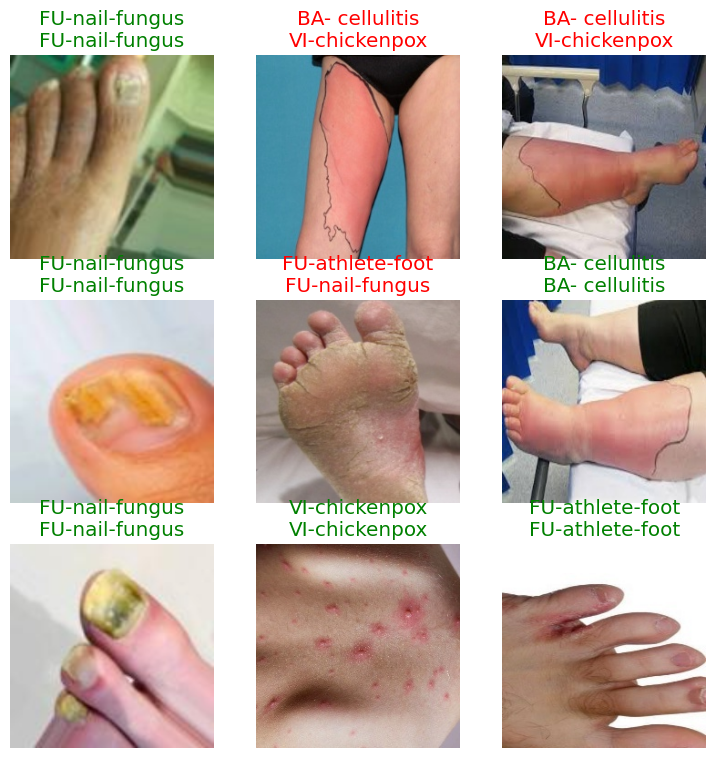

In [41]:
learner.show_results(shuffle=True)

In [42]:
from fastbook import *
from glob import glob
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

learn_inf = load_learner('Skin_disease.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [52]:
learn_inf.predict(f'{dataset_folder}/VI-shingles/100_VI-shingles (27).jpg')

('VI-shingles',
 tensor(7),
 tensor([7.1158e-04, 1.0830e-03, 6.1673e-03, 8.2173e-04, 1.0992e-03, 2.2557e-03, 8.2743e-04, 9.8703e-01]))

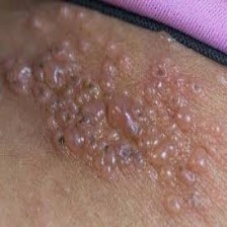

In [51]:
from PIL import Image
im = Image.open(f'{dataset_folder}/VI-shingles/100_VI-shingles (27).jpg')
im

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


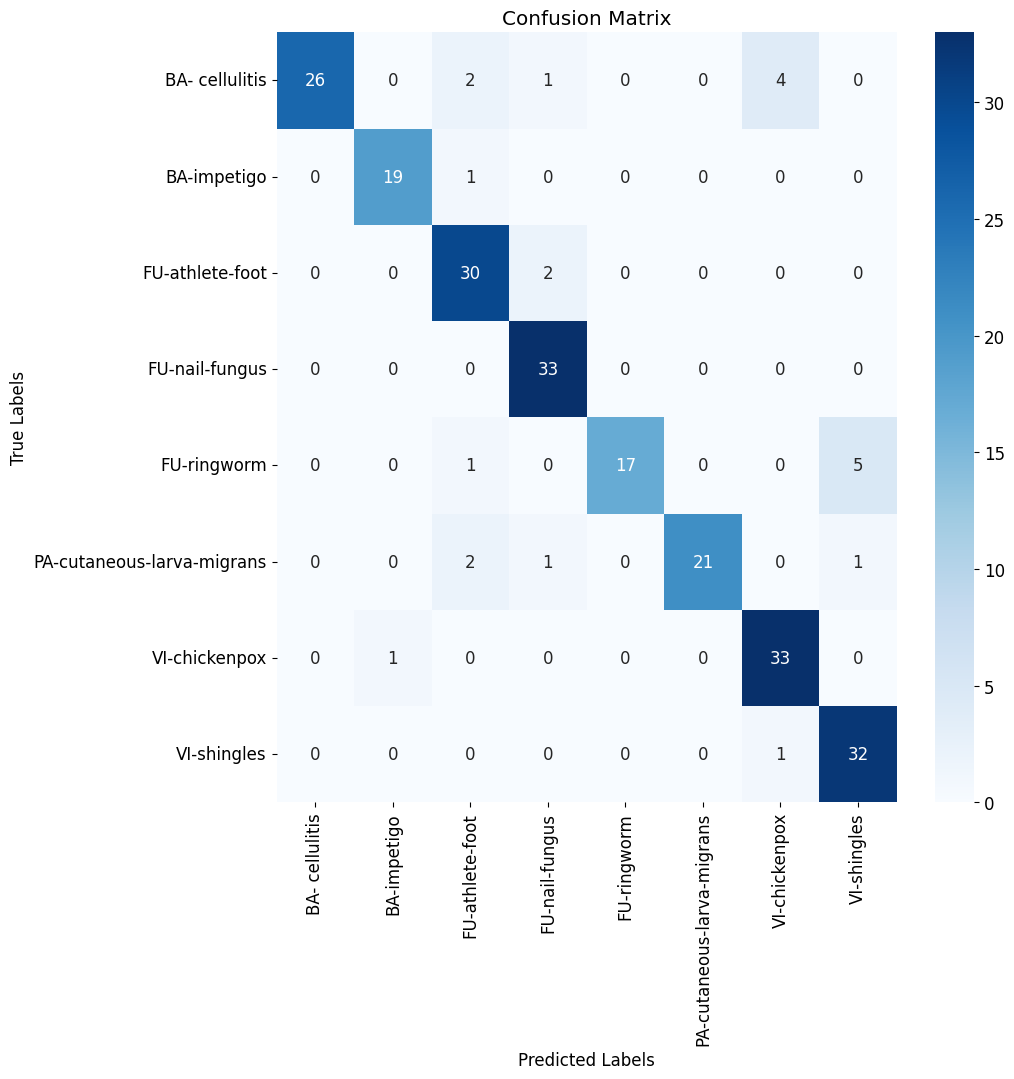

In [53]:
from fastai.vision.all import *
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_path = '/content/data/skin-disease-datasaet/test_set'

def parent_label(image_file):
  return os.path.basename(os.path.dirname(image_file))

image_files = get_image_files(test_path)
true_labels = [parent_label(image_file) for image_file in image_files]
learn_inf = load_learner('Skin_disease.pkl')
predictions = [learn_inf.predict(image_file) for image_file in image_files]
predicted_labels = [pred[0] for pred in predictions]
cm = confusion_matrix(true_labels, predicted_labels)
class_labels = sorted(list(set(true_labels)))
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(predicted_labels, true_labels))


                            precision    recall  f1-score   support

            BA- cellulitis       0.79      1.00      0.88        26
               BA-impetigo       0.95      0.95      0.95        20
           FU-athlete-foot       0.94      0.83      0.88        36
            FU-nail-fungus       1.00      0.89      0.94        37
               FU-ringworm       0.74      1.00      0.85        17
PA-cutaneous-larva-migrans       0.84      1.00      0.91        21
             VI-chickenpox       0.97      0.87      0.92        38
               VI-shingles       0.97      0.84      0.90        38

                  accuracy                           0.91       233
                 macro avg       0.90      0.92      0.90       233
              weighted avg       0.92      0.91      0.91       233



Deployment

In [55]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.9 MB/s eta 0:00:00


In [56]:
import streamlit as st
from PIL import Image

# Set the title of the app
st.title("Image Upload and Display App")

# Create a file uploader widget
uploaded_file = st.file_uploader("Choose an image file", type=["jpg", "jpeg", "png"])

# Check if a file is uploaded
if uploaded_file is not None:
    # Open the uploaded image file
    image = Image.open(uploaded_file)

    # Display the image
    st.image(image, caption="Uploaded Image", use_column_width=True)

    # Display the image properties
    st.write(f"Image format: {image.format}")
    st.write(f"Image size: {image.size}")
    st.write(f"Image mode: {image.mode}")

else:
    st.write("Please upload an image file to see the preview.")

2026-08-14 01:56:42.031 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.508 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-14 01:56:42.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-14 01:56:42.534 Thread 'MainThread': mi

base line

In [57]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from fastai.vision.all import *
from sklearn.metrics import confusion_matrix

In [58]:
set_seed(99, True)

In [59]:
data = {'Path': [], 'Class': []}

dataset_path = '/content/data/skin-disease-datasaet/train_set'

entries = os.listdir(dataset_path)

for entry in entries:
    full_path = os.path.join(dataset_path, entry)
    if os.path.isdir(full_path):
        files = os.listdir(full_path)
        for file in files:
            file_path = os.path.join(full_path, file)

            data['Path'].append(os.path.join(entry, file))
            data['Class'].append(entry)

df = pd.DataFrame(data)

In [60]:
df['Class'].value_counts()

,count
Class,
VI-chickenpox,136
BA- cellulitis,136
VI-shingles,130
FU-nail-fungus,129
FU-athlete-foot,124
PA-cutaneous-larva-migrans,100
FU-ringworm,90
BA-impetigo,80


In [61]:
df.Class = df.Class.str.replace('VI-chickenpox', 'chickenpox')
df.Class = df.Class.str.replace('BA- cellulitis', 'cellulitis')
df.Class = df.Class.str.replace('VI-shingles', 'shingles')
df.Class = df.Class.str.replace('FU-nail-fungus', 'nail fungus')
df.Class = df.Class.str.replace('FU-athlete-foot', 'athlete foot')
df.Class = df.Class.str.replace('PA-cutaneous-larva-migrans', 'cutaneous larva migrans')
df.Class = df.Class.str.replace('FU-ringworm', 'ring worm')
df.Class = df.Class.str.replace('BA-impetigo', 'impetigo')
df = df.sort_values(by='Class')

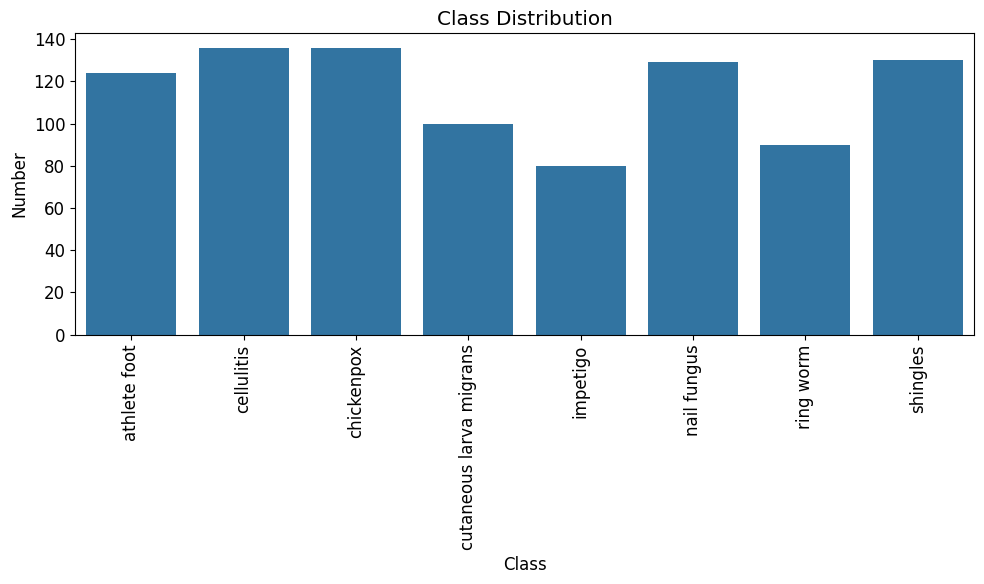

In [62]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number')
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('/content/data/skin-disease-datasaet')
plt.show()

Random

In [63]:
import random
classes = ['A','B','C']
random_prediction = random.choice(classes)
print(f"Random Prediction: {random_prediction}")

Random Prediction: B


In [64]:
import random

#สมมติว่ามี 3 คลาส
classes = ['A', 'B', 'C']

#สุ่มคลาส
random_prediction = random.choice(classes)
print(f"Random Prediction: {random_prediction}")

Random Prediction: B


In [70]:
import random
from sklearn.metrics import accuracy_score, f1_score

#สมมติว่ามี 3 คลาส
classes = ['A', 'B', 'C']

#สร้าง Ground Truth (ค่าจริง)
ground_truth = random.choice(classes)  # เช่น 'A'
print(f"Ground Truth: {ground_truth}")

#สุ่มคลาส (Random Prediction)
random_prediction = random.choice(classes)
print(f"Random Prediction: {random_prediction}")

#แปลงค่าจริงและค่าทำนายให้อยู่ในรูปแบบของ List (เพื่อใช้กับ sklearn)
y_true = [ground_truth]
y_pred = [random_prediction]

#คำนวณ Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2f}")

#คำนวณ F1 Score (average='macro' ไม่จำเป็นเพราะเป็น single prediction)
f1 = f1_score(y_true, y_pred, labels=classes, average='macro', zero_division=1)
print(f"F1 Score: {f1:.2f}")

Ground Truth: C
Random Prediction: C
Accuracy: 1.00
F1 Score: 1.00
